In [10]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import matplotlib.pyplot as plt


/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [11]:
!pip install dagshub mlflow --quiet

import mlflow
import dagshub
dagshub.init(repo_owner='ChorniBero15', repo_name='ML2', mlflow=True)

mlflow.set_experiment("XGBoost_Training")

Initialized MLflow to track repo "ChorniBero15/ML2"

Repository ChorniBero15/ML2 initialized!

<Experiment: artifact_location='mlflow-artifacts:/6b56f685bae1412694ea06577c61892c', creation_time=1777995031473, experiment_id='0', last_update_time=1777995031473, lifecycle_stage='active', name='XGBoost_Training', tags={}, trace_location=None, workspace='default'>

# Cleaning


In [12]:
def reduce_mem_usage(df, use_category=False):
    start_mem = df.memory_usage(deep=True).sum() / 1024 ** 2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if pd.api.types.is_integer_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        
        elif pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="float")
        
        elif use_category and col_type == "object":
            unique_ratio = df[col].nunique(dropna=False) / len(df)
            
            if unique_ratio < 0.5:
                df[col] = df[col].astype("category")
    
    end_mem = df.memory_usage(deep=True).sum() / 1024 ** 2
    reduction = 100 * (start_mem - end_mem) / start_mem
    
    print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB")
    print(f"Reduced by {reduction:.2f}%")
    
    return df

In [13]:
def safe_log_param(key, value):
    try:
        mlflow.log_param(key, value)
    except Exception as e:
        print(f"Could not log param {key}: {e}")


def safe_log_params(params):
    for key, value in params.items():
        safe_log_param(key, value)


def safe_log_metric(key, value):
    try:
        if value is not None and not pd.isna(value):
            mlflow.log_metric(key, float(value))
    except Exception as e:
        print(f"Could not log metric {key}: {e}")


def safe_log_artifact(path):
    try:
        if os.path.exists(path):
            mlflow.log_artifact(path)
        else:
            print(f"Artifact not found: {path}")
    except Exception as e:
        print(f"Could not log artifact {path}: {e}")


def start_mlflow_run(run_name):
    if mlflow.active_run():
        mlflow.end_run()
    
    return mlflow.start_run(run_name=run_name)

In [14]:
train_transaction_path = "/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv"
train_identity_path = "/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv"

test_identity_path = "/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv"
test_transaction_path = "/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv"

train_transaction = reduce_mem_usage(pd.read_csv(train_transaction_path))
train_identity = reduce_mem_usage(pd.read_csv(train_identity_path))

test_transaction = reduce_mem_usage(pd.read_csv(test_transaction_path))
test_identity = reduce_mem_usage(pd.read_csv(test_identity_path))

test_identity.columns = test_identity.columns.str.replace("-", "_", regex=False)
test_transaction.columns = test_transaction.columns.str.replace("-", "_", regex=False)

train = train_transaction.merge(train_identity, on="TransactionID", how="left")
test = test_transaction.merge(test_identity, on="TransactionID", how="left")

print("Merged train:", train.shape)
print("Merged test:", test.shape)

import gc

del train_transaction, test_transaction, train_identity, test_identity
gc.collect()

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

Memory usage: 2062.07 MB -> 1203.22 MB
Reduced by 41.65%
Memory usage: 143.14 MB -> 129.94 MB
Reduced by 9.22%
Memory usage: 1771.84 MB -> 1038.31 MB
Reduced by 41.40%
Memory usage: 140.08 MB -> 127.09 MB
Reduced by 9.27%
Merged train: (590540, 434)
Merged test: (506691, 433)
Memory usage: 1603.31 MB -> 1603.31 MB
Reduced by 0.00%
Memory usage: 1386.12 MB -> 1386.12 MB
Reduced by 0.00%


In [15]:
with start_mlflow_run("XGBoost_Cleaning"):
    safe_log_param("cleaning_method", "memory_downcasting_and_left_merge")
    safe_log_param("merge_key", "TransactionID")
    safe_log_param("merge_type", "left")
    safe_log_metric("train_rows", train.shape[0])
    safe_log_metric("train_columns", train.shape[1])
    safe_log_metric("test_rows", test.shape[0])
    safe_log_metric("test_columns", test.shape[1])
    safe_log_metric("fraud_rate", train["isFraud"].mean())
    safe_log_metric("train_missing_percent", train.isnull().mean().mean() * 100)
    safe_log_metric("test_missing_percent", test.isnull().mean().mean() * 100)
    safe_log_metric("train_duplicate_transaction_ids", train["TransactionID"].duplicated().sum())
    safe_log_metric("test_duplicate_transaction_ids", test["TransactionID"].duplicated().sum())

print("Cleaning metrics prepared for MLflow.")


🏃 View run XGBoost_Cleaning at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0/runs/a948dd674f8b4f2caa849a6501c2f820
🧪 View experiment at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0
Cleaning metrics prepared for MLflow.


# Feature Engineering


In [16]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [17]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols if cols is not None else []
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        existing_cols = [col for col in self.cols if col in X.columns]
        return X.drop(columns=existing_cols)



In [18]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.created_cols = [
            "TransactionAmt_log",
            "TransactionAmt_decimal",
            "Transaction_day",
            "Transaction_hour",
            "Transaction_week",
            "missing_count",
            "has_identity",
            "email_domain_match",
            "card_missing_count"
        ]
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X = X.drop(columns=[col for col in self.created_cols if col in X.columns], errors="ignore")
        
        features = pd.DataFrame(index=X.index)
        
        if "TransactionAmt" in X.columns:
            features["TransactionAmt_log"] = np.log1p(X["TransactionAmt"])
            features["TransactionAmt_decimal"] = ((X["TransactionAmt"] % 1) * 1000).round()
        
        if "TransactionDT" in X.columns:
            features["Transaction_day"] = X["TransactionDT"] // (24 * 60 * 60)
            features["Transaction_hour"] = (X["TransactionDT"] // (60 * 60)) % 24
            features["Transaction_week"] = features["Transaction_day"] // 7
        
        features["missing_count"] = X.isnull().sum(axis=1)
        
        if "id_01" in X.columns:
            features["has_identity"] = X["id_01"].notnull().astype("int8")
        else:
            features["has_identity"] = 0
        
        if "P_emaildomain" in X.columns and "R_emaildomain" in X.columns:
            features["email_domain_match"] = (X["P_emaildomain"] == X["R_emaildomain"]).astype("int8")
        else:
            features["email_domain_match"] = 0
        
        card_cols = [col for col in ["card1", "card2", "card3", "card4", "card5", "card6"] if col in X.columns]
        
        if len(card_cols) > 0:
            features["card_missing_count"] = X[card_cols].isnull().sum(axis=1)
        else:
            features["card_missing_count"] = 0
        
        return pd.concat([X, features], axis=1)

In [19]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols
        self.freq_maps = {}
    
    def _normalize_series(self, s):
        return s.astype("object").where(s.notnull(), "__MISSING__")
    
    def fit(self, X, y=None):
        if self.cols is None:
            self.cols_ = X.select_dtypes(include=["object", "category"]).columns.tolist()
        else:
            self.cols_ = [col for col in self.cols if col in X.columns]
        
        self.freq_maps = {}
        
        for col in self.cols_:
            normalized = self._normalize_series(X[col])
            self.freq_maps[col] = normalized.value_counts(dropna=False).to_dict()
        
        return self
    
    def transform(self, X):
        X = X.copy()
        new_features = pd.DataFrame(index=X.index)
        
        for col in self.cols_:
            if col in X.columns:
                normalized = self._normalize_series(X[col])
                new_features[f"{col}_freq"] = normalized.map(self.freq_maps[col]).fillna(0).astype("float32")
        
        return pd.concat([X, new_features], axis=1)


In [20]:
class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols
        self.category_maps = {}
    
    def _normalize_series(self, s):
        return s.astype("object").where(s.notnull(), "__MISSING__")
    
    def fit(self, X, y=None):
        if self.cols is None:
            self.cols_ = X.select_dtypes(include=["object", "category"]).columns.tolist()
        else:
            self.cols_ = [col for col in self.cols if col in X.columns]
        
        self.category_maps = {}
        
        for col in self.cols_:
            normalized = self._normalize_series(X[col])
            unique_values = pd.Series(normalized.unique())
            self.category_maps[col] = {value: idx for idx, value in enumerate(unique_values)}
        
        return self
    
    def transform(self, X):
        X = X.copy()
        
        for col in self.cols_:
            if col in X.columns:
                normalized = self._normalize_series(X[col])
                X[col] = normalized.map(self.category_maps[col]).fillna(-1).astype("int32")
        
        return X


In [21]:
class ReplaceInfValues(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X = X.replace([np.inf, -np.inf], np.nan)
        return X

In [22]:
class SimpleFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, max_missing_ratio=0.95, min_unique_values=2):
        self.max_missing_ratio = max_missing_ratio
        self.min_unique_values = min_unique_values

    def fit(self, X, y=None):
        X = X.copy()
        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        X_numeric = X[numeric_cols]

        missing_ratio = X_numeric.isnull().mean()
        unique_counts = X_numeric.nunique(dropna=False)

        self.selected_features_ = [
            col for col in numeric_cols
            if missing_ratio[col] <= self.max_missing_ratio
            and unique_counts[col] >= self.min_unique_values
        ]
        self.dropped_features_ = [col for col in numeric_cols if col not in self.selected_features_]

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.selected_features_:
            if col not in X.columns:
                X[col] = np.nan

        return X[self.selected_features_]


In [23]:
target = "isFraud"

X = train.drop(columns=[target])
y = train[target].astype("int8")

X_test = test.copy()

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (590540, 433)
y: (590540,)
X_test: (506691, 433)


In [24]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index].copy()
y_train = y.iloc[:split_index].copy()

X_val = X.iloc[split_index:].copy()
y_val = y.iloc[split_index:].copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("Train fraud rate:", y_train.mean())
print("Validation fraud rate:", y_val.mean())

X_train: (472432, 433)
X_val: (118108, 433)
Train fraud rate: 0.03513521522674162
Validation fraud rate: 0.034409184813899145


In [25]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative count:", negative_count)
print("Positive count:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative count: 455833
Positive count: 16599
scale_pos_weight: 27.46147358274595


In [26]:
freq_encode_cols = [
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2",
    "P_emaildomain", "R_emaildomain",
    "DeviceType", "DeviceInfo",
    "ProductCD",
    "id_30", "id_31", "id_33"
]

xgb_params = {
    "n_estimators": 1000,
    "learning_rate": 0.03,
    "max_depth": 5,
    "min_child_weight": 10,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "gamma": 0.1,
    "reg_alpha": 0.1,
    "reg_lambda": 2.0,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight
}

xgb_pipeline = Pipeline([
    ("drop_columns", DropColumns(cols=["TransactionID"])),
    ("feature_engineering", FeatureEngineering()),
    ("frequency_encoding", FrequencyEncoder(cols=freq_encode_cols)),
    ("categorical_encoding", CategoricalEncoder()),
    ("replace_inf", ReplaceInfValues()),
    ("feature_selection", SimpleFeatureSelector(max_missing_ratio=0.95, min_unique_values=2)),
    ("model", XGBClassifier(**xgb_params))
])

In [27]:
with start_mlflow_run("XGBoost_Feature_Engineering"):
    fe_pipeline = Pipeline([
        ("drop_columns", DropColumns(cols=["TransactionID"])),
        ("feature_engineering", FeatureEngineering()),
        ("frequency_encoding", FrequencyEncoder(cols=freq_encode_cols)),
        ("categorical_encoding", CategoricalEncoder()),
        ("replace_inf", ReplaceInfValues())
    ])

    fe_pipeline.fit(X_train, y_train)
    X_train_fe_sample = fe_pipeline.transform(X_train.iloc[:2000])

    safe_log_param("created_features", "TransactionAmt_log,TransactionAmt_decimal,Transaction_day,Transaction_hour,Transaction_week,missing_count,has_identity,email_domain_match,card_missing_count")
    safe_log_param("categorical_encoding", "ordinal_codes_fitted_on_training_split")
    safe_log_param("frequency_encoding_columns", ",".join(freq_encode_cols))
    safe_log_metric("features_after_engineering", X_train_fe_sample.shape[1])
    safe_log_metric("sample_rows_for_feature_engineering_check", X_train_fe_sample.shape[0])

print("Feature engineering metrics prepared for MLflow.")


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0/runs/b84b364708664ca6a7a2938a76a0a3c7
🧪 View experiment at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0
Feature engineering metrics prepared for MLflow.


# Training


In [28]:
with start_mlflow_run("XGBoost_Training_Validation"):
    xgb_pipeline.fit(X_train, y_train)

    train_pred_proba = xgb_pipeline.predict_proba(X_train)[:, 1]
    val_pred_proba = xgb_pipeline.predict_proba(X_val)[:, 1]
    val_pred = (val_pred_proba >= 0.5).astype(int)

    train_roc_auc = roc_auc_score(y_train, train_pred_proba)
    val_roc_auc = roc_auc_score(y_val, val_pred_proba)
    train_pr_auc = average_precision_score(y_train, train_pred_proba)
    val_pr_auc = average_precision_score(y_val, val_pred_proba)
    overfit_gap = train_roc_auc - val_roc_auc

    safe_log_params(xgb_params)
    safe_log_param("model_architecture", "XGBoost")
    safe_log_param("validation_strategy", "time_based_80_20_split")
    safe_log_param("pipeline_steps", ",".join(xgb_pipeline.named_steps.keys()))
    safe_log_metric("train_roc_auc", train_roc_auc)
    safe_log_metric("validation_roc_auc", val_roc_auc)
    safe_log_metric("train_pr_auc", train_pr_auc)
    safe_log_metric("validation_pr_auc", val_pr_auc)
    safe_log_metric("overfit_gap", overfit_gap)
    safe_log_metric("train_rows", X_train.shape[0])
    safe_log_metric("validation_rows", X_val.shape[0])
    safe_log_metric("train_fraud_rate", y_train.mean())
    safe_log_metric("validation_fraud_rate", y_val.mean())

    report_text = classification_report(y_val, val_pred)
    with open("xgboost_validation_classification_report.txt", "w") as f:
        f.write(report_text)
    pd.DataFrame(confusion_matrix(y_val, val_pred)).to_csv("xgboost_validation_confusion_matrix.csv", index=False)

    safe_log_artifact("xgboost_validation_classification_report.txt")
    safe_log_artifact("xgboost_validation_confusion_matrix.csv")

print("Validation ROC-AUC:", val_roc_auc)
print("Validation PR-AUC:", val_pr_auc)
print("Overfit gap:", overfit_gap)


🏃 View run XGBoost_Training_Validation at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0/runs/88ab0b7374b54a43a8a0598c2f8c5025
🧪 View experiment at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0
Validation ROC-AUC: 0.9126278244209929
Validation PR-AUC: 0.5258987578088574
Overfit gap: 0.05299910422667198


In [29]:
val_pred_proba = xgb_pipeline.predict_proba(X_val)[:, 1]
val_pred = (val_pred_proba >= 0.5).astype(int)

val_roc_auc = roc_auc_score(y_val, val_pred_proba)
val_pr_auc = average_precision_score(y_val, val_pred_proba)

print("Validation ROC-AUC:", val_roc_auc)
print("Validation PR-AUC:", val_pr_auc)

print("\nClassification report:")
print(classification_report(y_val, val_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_val, val_pred))

Validation ROC-AUC: 0.9126278244209929
Validation PR-AUC: 0.5258987578088574

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95    114044
           1       0.23      0.73      0.35      4064

    accuracy                           0.91    118108
   macro avg       0.61      0.82      0.65    118108
weighted avg       0.96      0.91      0.93    118108


Confusion matrix:
[[104292   9752]
 [  1107   2957]]


# Feature Selection


In [30]:
preprocessor = xgb_pipeline[:-1]
model = xgb_pipeline.named_steps["model"]

sample_transformed = preprocessor.transform(X_train.iloc[:5])
feature_names = sample_transformed.columns.tolist()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.head(30)

,feature,importance
310,V258,0.101148
122,V70,0.053818
18,C4,0.052984
270,V218,0.040328
346,V294,0.036301
143,V91,0.030506
22,C8,0.028712
210,V158,0.021368
253,V201,0.018276
360,V308,0.015599


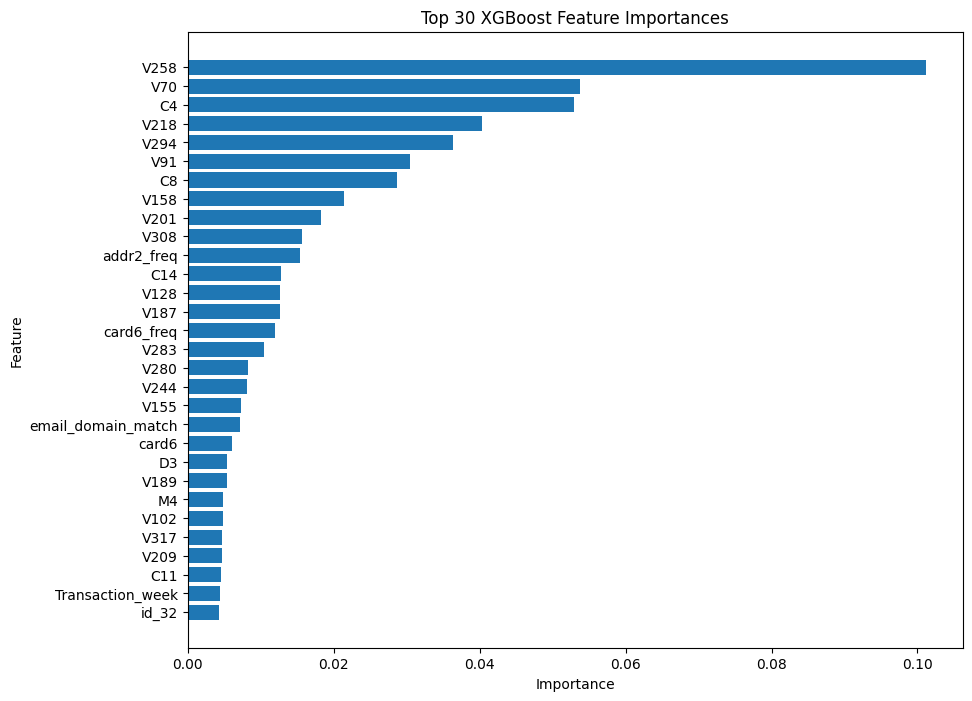

In [31]:
import matplotlib.pyplot as plt

top_importance = importance_df.head(30)

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.title("Top 30 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [33]:
import json
selected_top_features = importance_df.head(100)["feature"].tolist()

importance_df.to_csv("xgboost_feature_importance.csv", index=False)
with open("xgboost_top_100_features.json", "w") as f:
    json.dump(selected_top_features, f, indent=2)

selector = xgb_pipeline.named_steps["feature_selection"]

with start_mlflow_run("XGBoost_Feature_Selection"):
    safe_log_param("feature_selection_method_1", "drop_high_missing_and_constant_features_inside_pipeline")
    safe_log_param("feature_selection_method_2", "xgboost_feature_importance_top_100_for_analysis")
    safe_log_param("max_missing_ratio", selector.max_missing_ratio)
    safe_log_param("min_unique_values", selector.min_unique_values)
    safe_log_metric("pipeline_selected_feature_count", len(selector.selected_features_))
    safe_log_metric("pipeline_dropped_feature_count", len(selector.dropped_features_))
    safe_log_metric("importance_selected_top_n", len(selected_top_features))
    safe_log_artifact("xgboost_feature_importance.csv")
    safe_log_artifact("xgboost_top_100_features.json")

print("Feature selection artifacts prepared for MLflow.")
print("Selected inside pipeline:", len(selector.selected_features_))
print("Dropped inside pipeline:", len(selector.dropped_features_))


🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0/runs/cc3b11afc5b64b42a7ea5f79c6073704
🧪 View experiment at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0
Feature selection artifacts prepared for MLflow.
Selected inside pipeline: 450
Dropped inside pipeline: 7


In [34]:
final_xgb_params = xgb_params.copy()

full_negative_count = (y == 0).sum()
full_positive_count = (y == 1).sum()
full_scale_pos_weight = full_negative_count / full_positive_count

final_xgb_params["scale_pos_weight"] = full_scale_pos_weight

final_pipeline = Pipeline([
    ("drop_columns", DropColumns(cols=["TransactionID"])),
    ("feature_engineering", FeatureEngineering()),
    ("frequency_encoding", FrequencyEncoder(cols=freq_encode_cols)),
    ("categorical_encoding", CategoricalEncoder()),
    ("replace_inf", ReplaceInfValues()),
    ("feature_selection", SimpleFeatureSelector(max_missing_ratio=0.95, min_unique_values=2)),
    ("model", XGBClassifier(**final_xgb_params))
])

with start_mlflow_run("XGBoost_Final_Pipeline"):
    final_pipeline.fit(X, y)

    full_train_pred = final_pipeline.predict_proba(X)[:, 1]
    full_train_roc_auc = roc_auc_score(y, full_train_pred)
    full_train_pr_auc = average_precision_score(y, full_train_pred)

    safe_log_params(final_xgb_params)
    safe_log_param("model_architecture", "XGBoost")
    safe_log_param("model_saved_as", "sklearn_pipeline")
    safe_log_param("registered_model_name", REGISTERED_MODEL_NAME)
    safe_log_metric("full_train_roc_auc", full_train_roc_auc)
    safe_log_metric("full_train_pr_auc", full_train_pr_auc)
    safe_log_metric("full_train_rows", X.shape[0])
    safe_log_metric("full_train_fraud_rate", y.mean())

    joblib.dump(final_pipeline, "xgboost_final_pipeline.pkl")
    safe_log_artifact("xgboost_final_pipeline.pkl")

    if MLFLOW_ENABLED:
        mlflow.sklearn.log_model(
            sk_model=final_pipeline,
            artifact_path="pipeline",
            registered_model_name=REGISTERED_MODEL_NAME,
            input_example=X.head(5)
        )

print("Final pipeline trained.")
print("Full-train ROC-AUC sanity check:", full_train_roc_auc)
print("Full-train PR-AUC sanity check:", full_train_pr_auc)


🏃 View run XGBoost_Final_Pipeline at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0/runs/a00be1b15a6a43f6bca71f2841dd11e1
🧪 View experiment at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0


NameError: name 'REGISTERED_MODEL_NAME' is not defined

In [36]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)
mlflow.log_artifact("model.pkl")

mlflow.sklearn.log_model(
    sk_model=final_pipeline,
    artifact_path="model",
    registered_model_name="xgboost_model"
)

2026/05/05 19:19:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 19:19:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'xgboost_model'.
2026/05/05 19:19:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost_model, version 1
Created version '1' of model 'xgboost_model'.


In [37]:
test_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

In [41]:
test_ids = test["TransactionID"].copy()
submission = pd.DataFrame({
    "TransactionID": test_ids,
    "isFraud": test_pred_proba
})


In [42]:
submission.to_csv("submission.csv", index=False)

submission.head()

,TransactionID,isFraud
0,3663549,0.035709
1,3663550,0.060203
2,3663551,0.035437
3,3663552,0.050776
4,3663553,0.065173


In [43]:
with start_mlflow_run("XGBoost_Submission"):
    safe_log_metric("submission_rows", submission.shape[0])
    safe_log_artifact("submission.csv")

print("Submission artifact prepared for MLflow.")


🏃 View run placid-smelt-339 at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0/runs/ee423b4287084e6296d3e81f5a498cb1
🧪 View experiment at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0
🏃 View run XGBoost_Submission at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0/runs/6b34a912d21c4915b98281b20ffe7d3f
🧪 View experiment at: https://dagshub.com/ChorniBero15/ML2.mlflow/#/experiments/0
Submission artifact prepared for MLflow.
